In [4]:
import torch
import torchvision
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms 
import numpy as np
import matplotlib.pyplot as plt 
import torch.nn as nn
import torch.optim as optim

SEED = 42
VAL = 0.2
BATCH = 64

torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


device: cpu


In [5]:
full_train_dataset = datasets.EMNIST(
    split="balanced",
    root="./data",
    train=True,
    download=True,
    transform=transform
)

In [6]:
train_size = int((1 - VAL) * len(full_train_dataset))
val_size = int(VAL * len(full_train_dataset))

print(train_size, val_size)

train_dataset, val_dataset = random_split(
    full_train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

90240 22560


In [7]:
test_dataset = datasets.EMNIST(
    split="balanced",
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [8]:
train_loader = DataLoader(train_dataset, BATCH, shuffle=True)
val_loader = DataLoader(val_dataset, BATCH, shuffle=False)
test_loader = DataLoader(test_dataset, BATCH, shuffle=False)

In [9]:
print(f"Full dataset: {len(full_train_dataset)}\ntrain:{len(train_dataset)}\nval:{len(val_dataset)}\ntest:{len(test_dataset)}\nclasses: {full_train_dataset.classes}")
for i, (data, target) in enumerate(train_loader):
    print(f"Batch {i}:\nTarget shape: {target.shape}\nData shape: {data.shape}")
    print(f"First 5 signs: {target[:5].numpy()}")
    if i == 4:
        break

Full dataset: 112800
train:90240
val:22560
test:18800
classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
Batch 0:
Target shape: torch.Size([64])
Data shape: torch.Size([64, 1, 28, 28])
First 5 signs: [32  3 36 29 28]
Batch 1:
Target shape: torch.Size([64])
Data shape: torch.Size([64, 1, 28, 28])
First 5 signs: [23  8 30  2 45]
Batch 2:
Target shape: torch.Size([64])
Data shape: torch.Size([64, 1, 28, 28])
First 5 signs: [ 7 15  6 18 15]
Batch 3:
Target shape: torch.Size([64])
Data shape: torch.Size([64, 1, 28, 28])
First 5 signs: [29 21 28 25 21]
Batch 4:
Target shape: torch.Size([64])
Data shape: torch.Size([64, 1, 28, 28])
First 5 signs: [ 3 39 14 33  6]


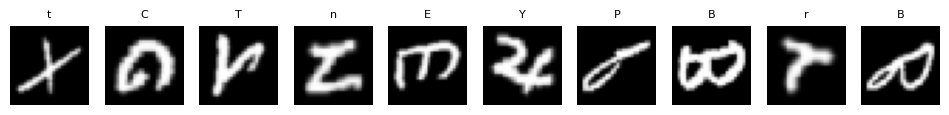

In [10]:
class_names = full_train_dataset.classes
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)
     


In [11]:
class MLP(nn.Module):
    def __init__(self, input_dim: int = 28 * 28, hidden_dims: tuple = (256, 128), num_classes: int = len(class_names), dropout: float = 0.0, batchnorm: bool = True):
        super().__init__()
        layers = [nn.Flatten()]
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(p=dropout))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [12]:
x_batch, y_batch = next(iter(train_loader))

In [13]:
model = MLP().to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print(f"logits: {out.shape}")
print(model)

logits: torch.Size([64, 47])
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=47, bias=True)
  )
)


In [14]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    return total_loss / n_batches, total_acc / n_batches 

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
        
    return total_loss / n_batches, total_acc / n_batches 

In [15]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [16]:
def fit(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        epochs: int = 20,
        verbose: bool = True,
        early_stopping = None
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_acc"].append(tr_acc)
        history["train_loss"].append(tr_loss)
        history["val_acc"].append(va_acc)
        history["val_loss"].append(va_loss)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )
        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [17]:
def plot_history(history: dict, title: str = "", save: bool = False, path: str = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    if save:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(epochs, history["train_loss"], label="train_loss")
        axes[0].plot(epochs, history["val_loss"], label="val_loss")
        axes[0].set_xlabel("epoch")
        axes[0].set_ylabel("loss")
        axes[0].set_title((title + " (loss)") if title else "loss")
        axes[0].legend()
        axes[0].grid(True)
        
        axes[1].plot(epochs, history["train_acc"], label="train_acc")
        axes[1].plot(epochs, history["val_acc"], label="val_acc")
        axes[1].set_xlabel("epoch")
        axes[1].set_ylabel("accuracy")
        axes[1].set_title((title + " (accuracy)") if title else "accuracy")
        axes[1].legend()
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.savefig(path, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Plot saved to {path}")

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

epoch 01/10 | train loss=0.9514, acc=0.7129 | val loss=0.6563, acc=0.7903
epoch 02/10 | train loss=0.5627, acc=0.8133 | val loss=0.5521, acc=0.8198
epoch 03/10 | train loss=0.4776, acc=0.8359 | val loss=0.5232, acc=0.8257
epoch 04/10 | train loss=0.4256, acc=0.8499 | val loss=0.5185, acc=0.8309
epoch 05/10 | train loss=0.3919, acc=0.8591 | val loss=0.5133, acc=0.8321
epoch 06/10 | train loss=0.3632, acc=0.8667 | val loss=0.5063, acc=0.8384
epoch 07/10 | train loss=0.3379, acc=0.8742 | val loss=0.5245, acc=0.8335
epoch 08/10 | train loss=0.3148, acc=0.8803 | val loss=0.5448, acc=0.8296
epoch 09/10 | train loss=0.3000, acc=0.8842 | val loss=0.5512, acc=0.8395
epoch 10/10 | train loss=0.2832, acc=0.8908 | val loss=0.5785, acc=0.8298


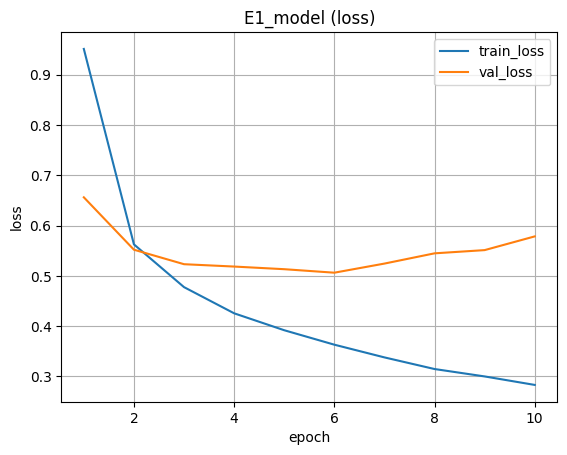

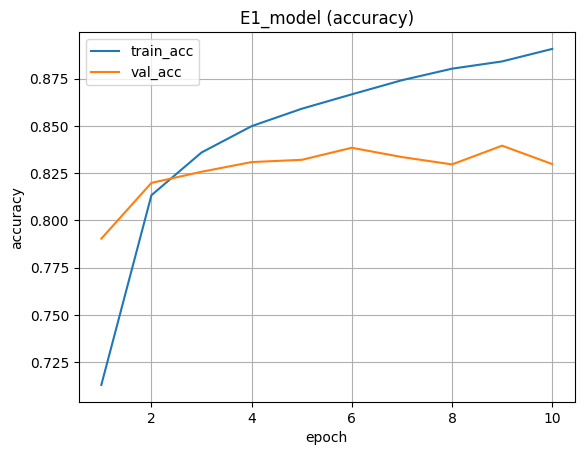

In [18]:
#Эксперимент E1

E1_model = MLP(hidden_dims=(256, 128), batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(E1_model.parameters(), lr=1e-3)

history_E1 = fit(
    E1_model, 
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=10
)

plot_history(history_E1, title="E1_model")

epoch 01/10 | train loss=1.1516, acc=0.6545 | val loss=0.6736, acc=0.7867
epoch 02/10 | train loss=0.7388, acc=0.7628 | val loss=0.5788, acc=0.8106
epoch 03/10 | train loss=0.6517, acc=0.7860 | val loss=0.5404, acc=0.8206
epoch 04/10 | train loss=0.6008, acc=0.7996 | val loss=0.5221, acc=0.8292
epoch 05/10 | train loss=0.5784, acc=0.8037 | val loss=0.5050, acc=0.8334
epoch 06/10 | train loss=0.5568, acc=0.8095 | val loss=0.4989, acc=0.8340
epoch 07/10 | train loss=0.5360, acc=0.8168 | val loss=0.4954, acc=0.8374
epoch 08/10 | train loss=0.5267, acc=0.8201 | val loss=0.4839, acc=0.8378
epoch 09/10 | train loss=0.5107, acc=0.8224 | val loss=0.4892, acc=0.8373
epoch 10/10 | train loss=0.5063, acc=0.8229 | val loss=0.4767, acc=0.8408


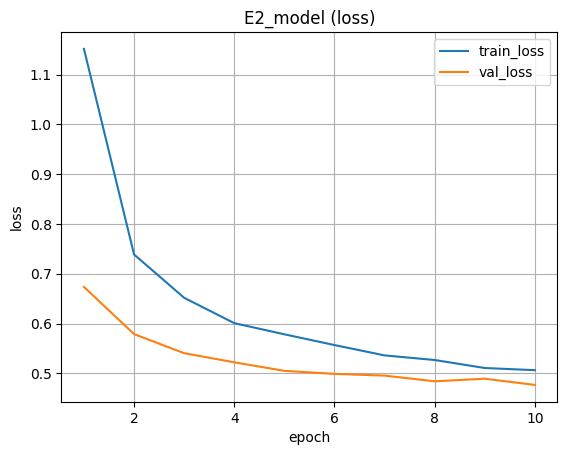

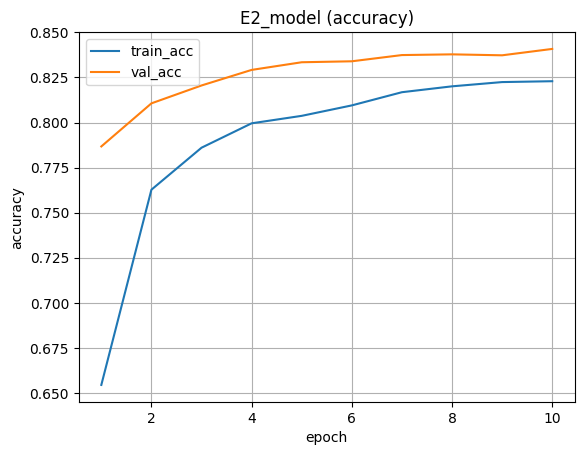

In [19]:
#Эксперимент E2

E2_model = MLP(hidden_dims=(256, 128), batchnorm=False, dropout=0.2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(E2_model.parameters(), lr=1e-3)

history_E2 = fit(
    E2_model, 
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=10
)

plot_history(history_E2, title="E2_model")

epoch 01/10 | train loss=0.9189, acc=0.7353 | val loss=0.5730, acc=0.8138
epoch 02/10 | train loss=0.5365, acc=0.8198 | val loss=0.5007, acc=0.8348
epoch 03/10 | train loss=0.4655, acc=0.8403 | val loss=0.4745, acc=0.8400
epoch 04/10 | train loss=0.4224, acc=0.8515 | val loss=0.4714, acc=0.8421
epoch 05/10 | train loss=0.3889, acc=0.8608 | val loss=0.4495, acc=0.8511
epoch 06/10 | train loss=0.3663, acc=0.8671 | val loss=0.4517, acc=0.8451
epoch 07/10 | train loss=0.3453, acc=0.8731 | val loss=0.4444, acc=0.8505
epoch 08/10 | train loss=0.3278, acc=0.8785 | val loss=0.4518, acc=0.8500
epoch 09/10 | train loss=0.3126, acc=0.8822 | val loss=0.4465, acc=0.8531
epoch 10/10 | train loss=0.2975, acc=0.8874 | val loss=0.4574, acc=0.8514


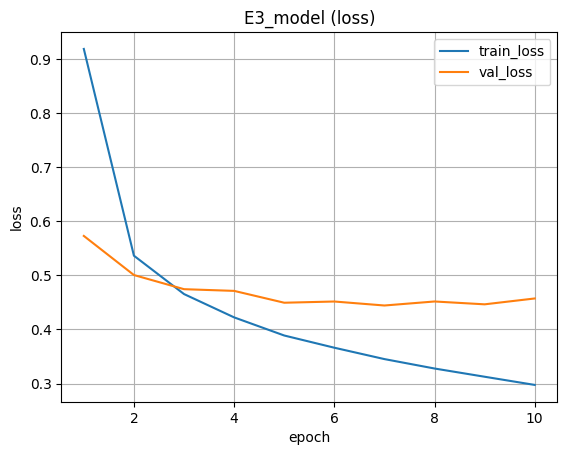

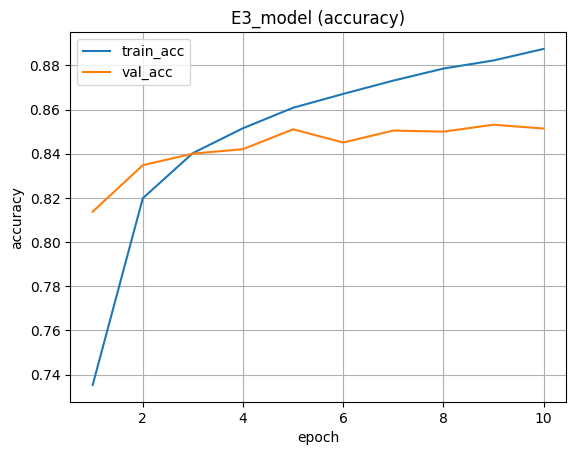

In [20]:
#Эксперимент E3

E3_model = MLP(hidden_dims=(256, 128), batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(E3_model.parameters(), lr=1e-3)

history_E3 = fit(
    E3_model, 
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=10
)

plot_history(history_E3, title="E3_model")

epoch 01/25 | train loss=0.9268, acc=0.7341 | val loss=0.5755, acc=0.8143
epoch 02/25 | train loss=0.5379, acc=0.8213 | val loss=0.5014, acc=0.8315
epoch 03/25 | train loss=0.4655, acc=0.8401 | val loss=0.4776, acc=0.8426
epoch 04/25 | train loss=0.4217, acc=0.8519 | val loss=0.4529, acc=0.8476
epoch 05/25 | train loss=0.3898, acc=0.8613 | val loss=0.4480, acc=0.8465
epoch 06/25 | train loss=0.3651, acc=0.8672 | val loss=0.4620, acc=0.8426
epoch 07/25 | train loss=0.3428, acc=0.8751 | val loss=0.4485, acc=0.8480
epoch 08/25 | train loss=0.3304, acc=0.8778 | val loss=0.4487, acc=0.8538
epoch 09/25 | train loss=0.3117, acc=0.8840 | val loss=0.4451, acc=0.8518
epoch 10/25 | train loss=0.2975, acc=0.8873 | val loss=0.4621, acc=0.8511
epoch 11/25 | train loss=0.2863, acc=0.8905 | val loss=0.4663, acc=0.8497
epoch 12/25 | train loss=0.2751, acc=0.8946 | val loss=0.4714, acc=0.8489
EarlyStopping: остановка на эпохе 12. Лучший val_acc=0.8538
Plot saved to artifacts/figures/curves_best.png


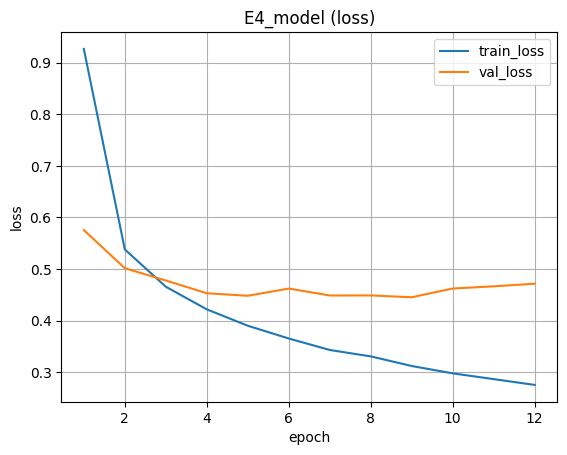

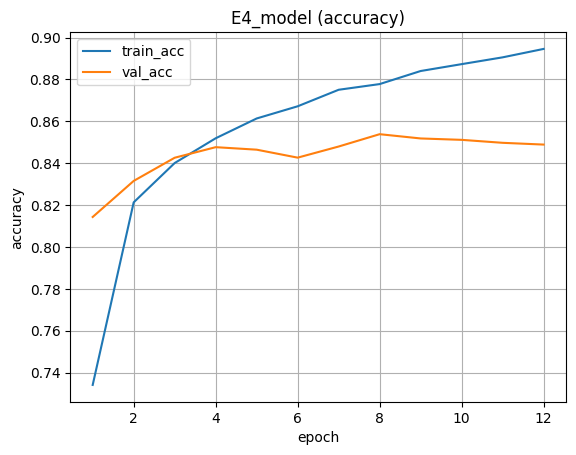

In [21]:
#Эксперимент E4

E4_model = MLP(hidden_dims=(256, 128), batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(E4_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4)

history_E4 = fit(
    E4_model, 
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=25,
    early_stopping=es
)

plot_history(history_E4, title="E4_model", save=True, path="artifacts/figures/curves_best.png")

In [22]:
test_loss, test_acc = evaluate(E4_model, test_loader, criterion, device)
print(f"Best model (E4) test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Best model (E4) test: loss=0.4674, acc=0.8503


In [23]:
torch.save(E4_model.state_dict(), 'artifacts/best_model.pt')

epoch 01/5 | train loss=1.2069, acc=0.6387 | val loss=0.9591, acc=0.7019
epoch 02/5 | train loss=0.8844, acc=0.7222 | val loss=0.8526, acc=0.7313
epoch 03/5 | train loss=0.8157, acc=0.7413 | val loss=0.6964, acc=0.7842
epoch 04/5 | train loss=0.7724, acc=0.7555 | val loss=0.6977, acc=0.7687
epoch 05/5 | train loss=0.7320, acc=0.7649 | val loss=0.6908, acc=0.7844
Plot saved to artifacts/figures/curves_lr_extremes_01.png


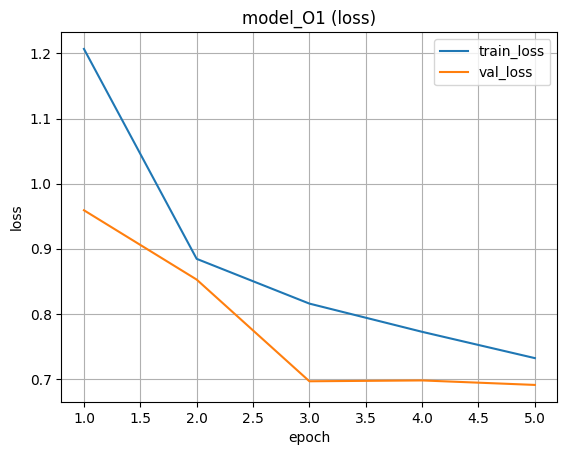

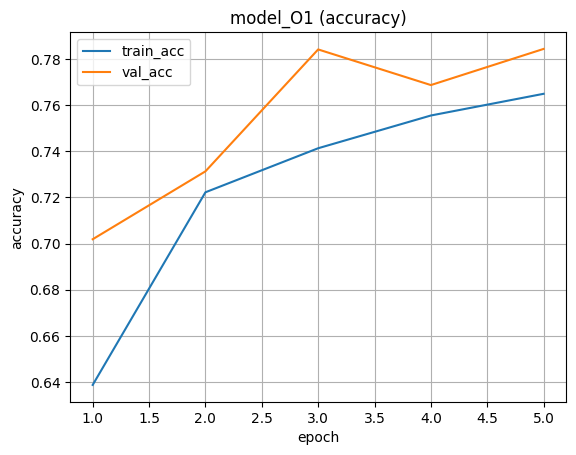

In [24]:
#Эксперимент O1

model_O1 = MLP(hidden_dims=(256, 128), batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_O1.parameters(), lr=1e-1)

history_O1 = fit(
    model_O1, 
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=5,
)

plot_history(history_O1, title="model_O1", save=True, path="artifacts/figures/curves_lr_extremes_01.png")

epoch 01/5 | train loss=3.3215, acc=0.2504 | val loss=2.8966, acc=0.4448
epoch 02/5 | train loss=2.6751, acc=0.5050 | val loss=2.4550, acc=0.5564
epoch 03/5 | train loss=2.2980, acc=0.5788 | val loss=2.1164, acc=0.6111
epoch 04/5 | train loss=2.0104, acc=0.6199 | val loss=1.8617, acc=0.6425
epoch 05/5 | train loss=1.7800, acc=0.6477 | val loss=1.6599, acc=0.6658
Plot saved to artifacts/figures/curves_lr_extremes_02.png


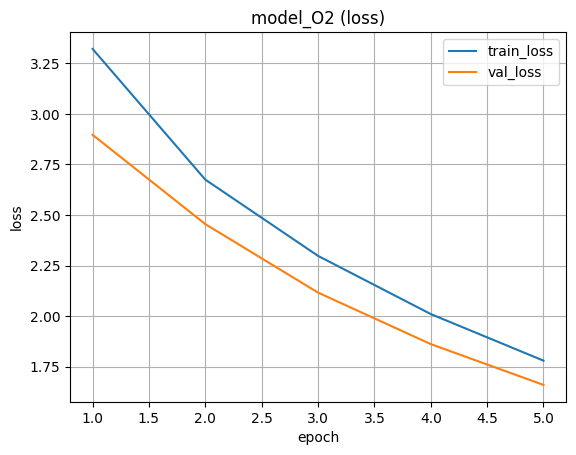

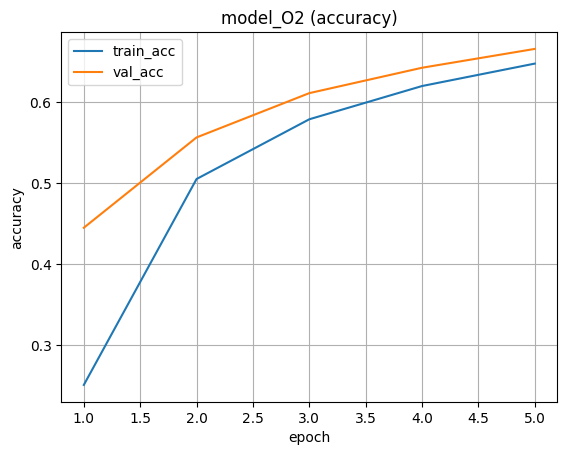

In [25]:
#Эксперимент O2

model_O2 = MLP(hidden_dims=(256, 128), batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_O2.parameters(), lr=1e-5)

history_O2 = fit(
    model_O2, 
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=5,
)

plot_history(history_O2, title="model_O2", save=True, path="artifacts/figures/curves_lr_extremes_02.png")

epoch 01/10 | train loss=1.9358, acc=0.5691 | val loss=1.1456, acc=0.7086
epoch 02/10 | train loss=0.9703, acc=0.7370 | val loss=0.7959, acc=0.7756
epoch 03/10 | train loss=0.7398, acc=0.7846 | val loss=0.6748, acc=0.7990
epoch 04/10 | train loss=0.6312, acc=0.8092 | val loss=0.6028, acc=0.8137
epoch 05/10 | train loss=0.5649, acc=0.8247 | val loss=0.5606, acc=0.8219
epoch 06/10 | train loss=0.5203, acc=0.8347 | val loss=0.5363, acc=0.8299
epoch 07/10 | train loss=0.4872, acc=0.8437 | val loss=0.5262, acc=0.8291
epoch 08/10 | train loss=0.4634, acc=0.8493 | val loss=0.5051, acc=0.8346
epoch 09/10 | train loss=0.4394, acc=0.8549 | val loss=0.4933, acc=0.8371
epoch 10/10 | train loss=0.4209, acc=0.8590 | val loss=0.4870, acc=0.8407


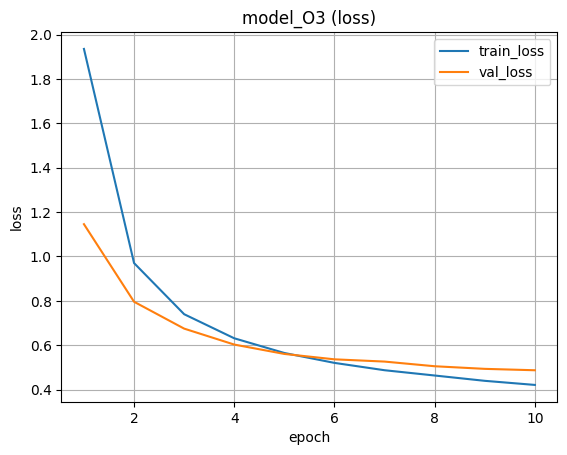

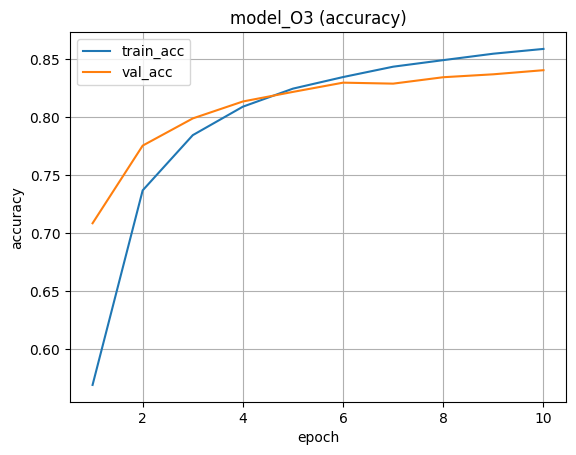

In [26]:
#Эксперимент O3

model_O3 = MLP(hidden_dims=(256, 128), batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_O3.parameters(), momentum=0.9, weight_decay=1e-4, lr=1e-3)

history_O3 = fit(
    model_O3, 
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=10,
)

plot_history(history_O3, title="model_O3")

In [27]:
from PIL import Image

img1 = Image.open("artifacts/figures/curves_lr_extremes_01.png")
img2 = Image.open("artifacts/figures/curves_lr_extremes_02.png")

total_height = img1.height + img2.height
max_width = max(img1.width, img2.width)

combined_image = Image.new('RGBA', (max_width, total_height))

combined_image.paste(img1, (0, 0))

combined_image.paste(img2, (0, img1.height))

combined_image.save("artifacts/figures/curves_lr_extremes.png")